K-means in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [3]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [4]:
# troviamo il numero k ottimale attraverso elbow method

wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

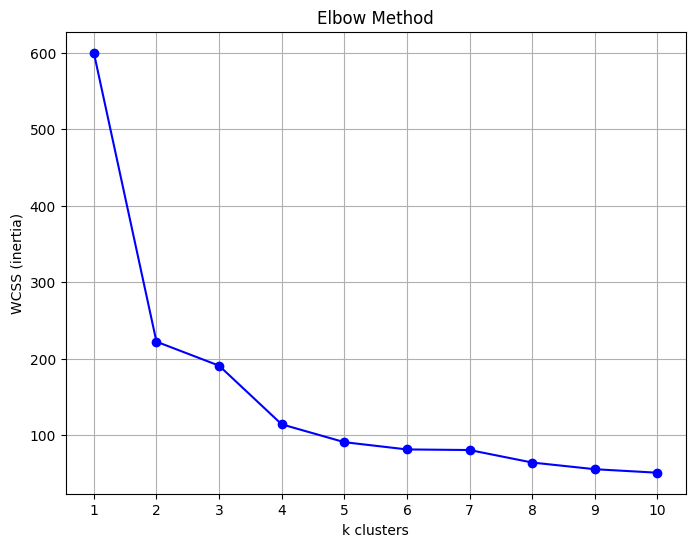

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, marker="o", color="blue")
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid()
plt.show()

In [10]:
# andiamo a fare il k-means con k=3 trovato
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_std)
centroids = kmeans.cluster_centers_
iter = kmeans.n_iter_
print(f"Iterations:\t{iter}")
print(f"Centroidi:\t{centroids}")

Iterations:	4
Centroidi:	[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


In [11]:
# rappresentazione grafica dei dati con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

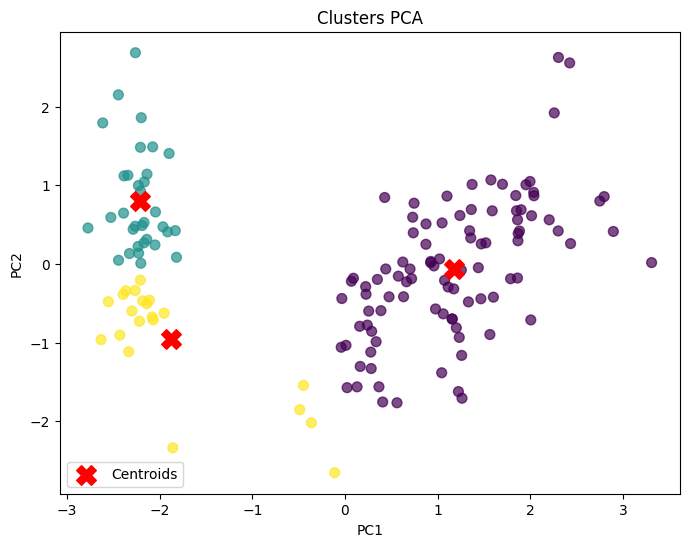

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
# dobbiamo anche ridurre i centroidi con PCA per poterli visualizzare
plt.scatter(
    pca.transform(centroids)[:, 0], 
    pca.transform(centroids)[:, 1], 
    c='red', 
    marker='X', 
    s=200, 
    label='Centroids'
)
plt.title("Clusters PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

C:\Users\chian\AppData\Local\Temp\ipykernel_13000\671863004.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


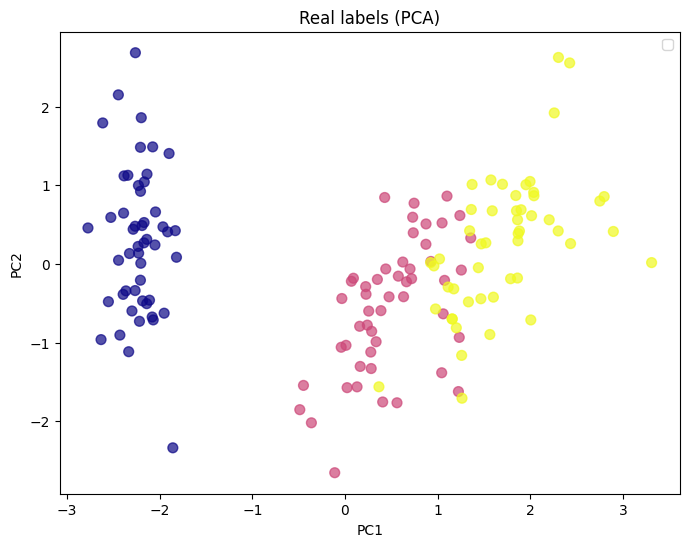

In [13]:
# vediamo le label originali del grafico
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', s=50, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Real labels (PCA)")
plt.legend()
plt.show()